In [1]:
from palmerpenguins import load_penguins
import matplotlib.pyplot as plt
import seaborn as sns

## Load Palmerpenguins dataset
Data: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/),
Palmer Station Antarctica LTER.
### About the data
Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.
The palmerpenguins package contains two datasets - _penguins_ and _penguins_raw_



In [2]:
# Load the clean dataset
penguins = load_penguins().dropna()
# Display the first few rows
print(penguins.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
4       3450.0  female  2007  
5       3650.0    male  2007  


## Uncovering Simpson's Paradox

This computation calculates the correlation between bill length and bill depth. When evaluated altogether, the variables appear negatively correlated. However, when split by species, they are highly positively correlated—a classic statistical phenomenon known as Simpson's Paradox.

In [3]:
print(f"Overall Correlation: {penguins['bill_length_mm'].corr(penguins['bill_depth_mm']):.2f}")
for species, group in penguins.groupby('species'):
    spec_corr = group['bill_length_mm'].corr(group['bill_depth_mm'])
    print(f"{species} Correlation: {spec_corr:.2f}")



Overall Correlation: -0.23
Adelie Correlation: 0.39
Chinstrap Correlation: 0.65
Gentoo Correlation: 0.65


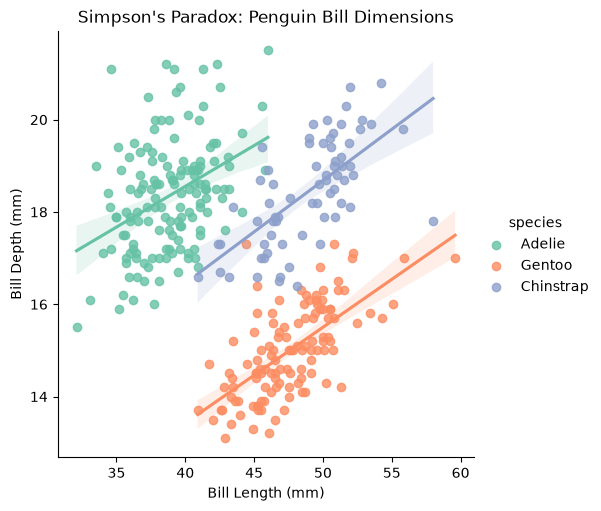

In [4]:
# Graph the paradox
sns.lmplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", palette="Set2")
plt.title("Simpson's Paradox: Penguin Bill Dimensions")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.show()

## The "Body Condition Index

This block constructs a custom engineering metric: a Body Condition Index (BCI). BCI calculates how many grams of body mass a penguin carries per millimeter of flipper length, highlighting which species and sex are the most robustly built relative to their frame.

In [5]:
penguins['bci'] = penguins['body_mass_g'] / penguins['flipper_length_mm']

# Rank profiles by demographic subgroup
bci_profile = penguins.groupby(['species', 'sex'])['bci'].mean().reset_index()
print(bci_profile.sort_values(by='bci', ascending=False))


     species     sex        bci
5     Gentoo    male  24.762056
4     Gentoo  female  21.996526
1     Adelie    male  21.017003
3  Chinstrap    male  19.685535
2  Chinstrap  female  18.401982
0     Adelie  female  17.943739


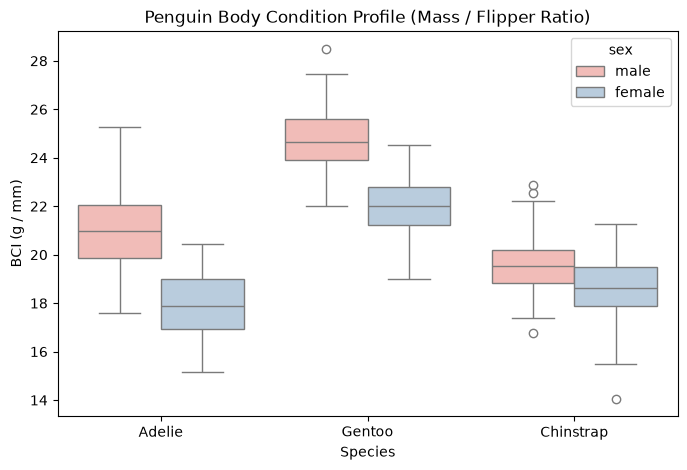

In [6]:
# Graph the distribution profile
plt.figure(figsize=(8, 5))
sns.boxplot(data=penguins, x="species", y="bci", hue="sex", palette="Pastel1")
plt.title("Penguin Body Condition Profile (Mass / Flipper Ratio)")
plt.xlabel("Species")
plt.ylabel("BCI (g / mm)")
plt.show()

* **What we did**: We loaded the dataset using the standalone package and analyzed how penguin body parts scale together.
* **Finding 1 (Simpson's Paradox)**: If you mix all penguins together, bills look like they get flatter as they get longer. But when looked at species by species, bills actually get longer and deeper together.
* **Finding 2 (Body Condition)**: We calculated weight relative to wing size. We found that Gentoo penguins are the most robustly built species, and males are consistently bulkier than females across all species.